In [1]:
import sys
sys.path.append("../")

from src.io import read_sensor_metadata

file = "../data/2023-03-01/Accelerometer/21S2X-20230301_000511.txt"

meta = read_sensor_metadata(file)
meta

{'Station_code': 'GMS05',
 'Sampling_rate': '100.0000',
 'Start_date': '01.03.2023',
 'Start_time': '00:05:11.800',
 'data_start_line': 4,
 'channel': '21S2Xcm/s2',
 'sampling_rate_hz': 100.0}

In [2]:
from src.io import read_sensor_sample

meta, df = read_sensor_sample(file, nrows=100_000)

df.head()

,time_sec,accel_cm_s2,accel_m_s2
0,0.00,-0.006755,-0.000068
1,0.01,0.023641,0.000236
2,0.02,0.030655,0.000307
3,0.03,-0.011691,-0.000117
4,0.04,-0.007534,-0.000075


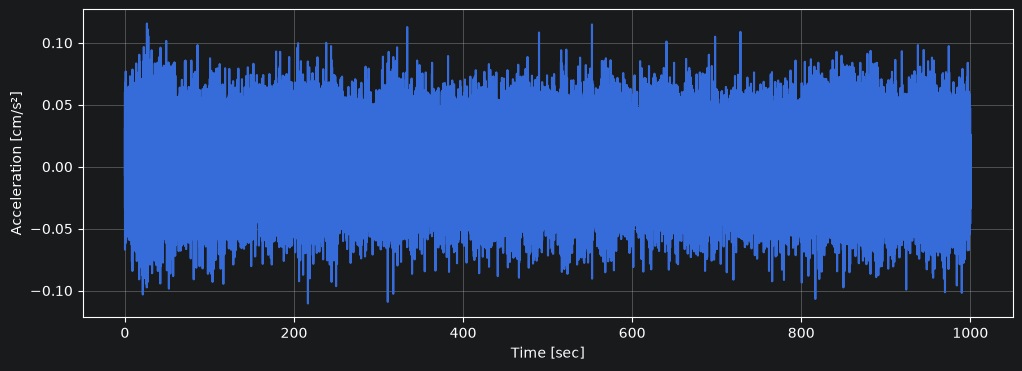

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df["time_sec"], df["accel_cm_s2"])
plt.xlabel("Time [sec]")
plt.ylabel("Acceleration [cm/s²]")
plt.grid(True)
plt.show()

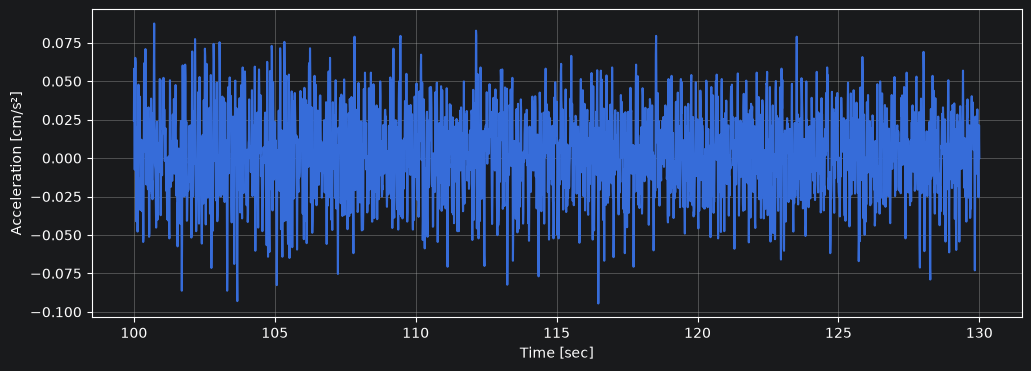

In [4]:
plt.figure(figsize=(12,4))

mask = (df["time_sec"] >= 100) & (df["time_sec"] <= 130)

plt.plot(
    df.loc[mask, "time_sec"],
    df.loc[mask, "accel_cm_s2"]
)

plt.xlabel("Time [sec]")
plt.ylabel("Acceleration [cm/s²]")
plt.grid(True)
plt.show()

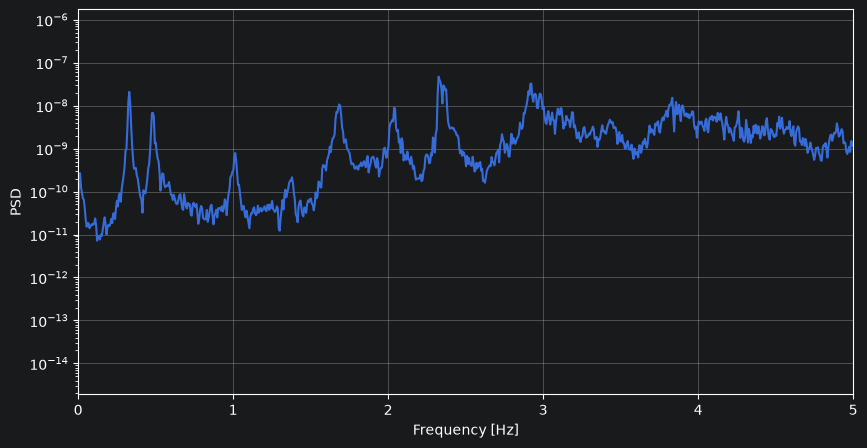

In [6]:
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

x = df["accel_m_s2"].values
x = x - np.mean(x)

Fs = meta["sampling_rate_hz"]

f, Pxx = welch(
    x,
    fs=Fs,
    nperseg=16384
)

plt.figure(figsize=(10,5))
plt.semilogy(f, Pxx)

plt.xlim(0,5)

plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.grid(True)

plt.show()

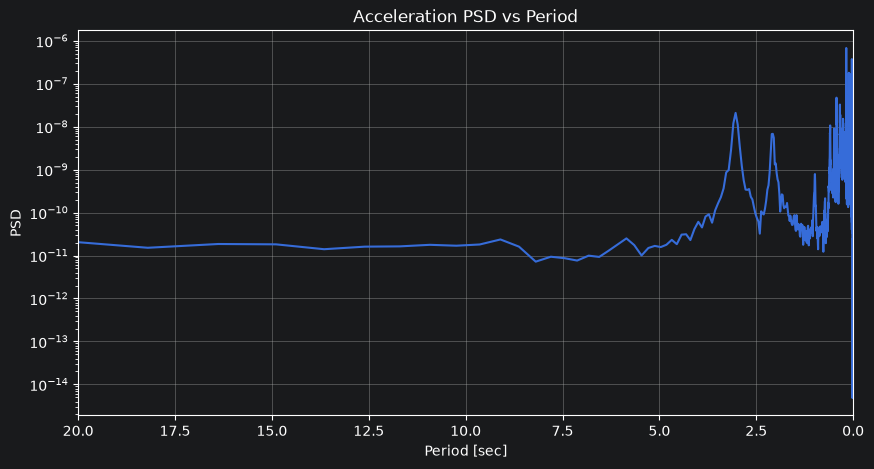

In [7]:
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

x = df["accel_m_s2"].values
x = x - np.mean(x)

Fs = meta["sampling_rate_hz"]

f, Pxx = welch(
    x,
    fs=Fs,
    nperseg=16384
)

# remove zero frequency because T = 1/f blows up at f = 0
mask = f > 0

T = 1 / f[mask]
P = Pxx[mask]

plt.figure(figsize=(10,5))
plt.semilogy(T, P)

plt.xlim(0, 20)
plt.gca().invert_xaxis()  # optional: long periods on left, short periods on right

plt.xlabel("Period [sec]")
plt.ylabel("PSD")
plt.title("Acceleration PSD vs Period")
plt.grid(True)
plt.show()

C:\Users\am1\AppData\Local\Temp\ipykernel_35780\1992316072.py:10: UserWarning: nperseg=131072 is greater than signal length max(len(x), len(y)) = 100000, using nperseg = 100000
  f, Pxx = welch(


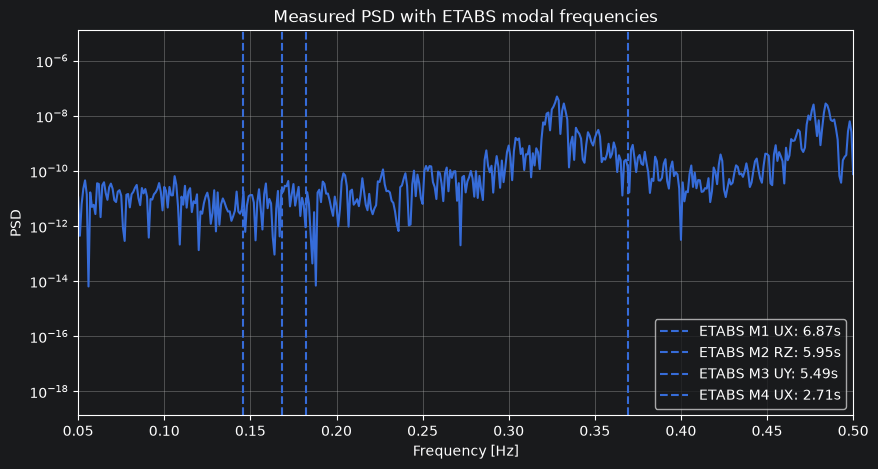

In [8]:
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

x = df["accel_m_s2"].values
x = x - np.mean(x)

Fs = meta["sampling_rate_hz"]

f, Pxx = welch(
    x,
    fs=Fs,
    nperseg=131072
)

plt.figure(figsize=(10,5))
plt.semilogy(f, Pxx)

plt.xlim(0.05, 0.50)

plt.axvline(1/6.87, linestyle="--", label="ETABS M1 UX: 6.87s")
plt.axvline(1/5.95, linestyle="--", label="ETABS M2 RZ: 5.95s")
plt.axvline(1/5.49, linestyle="--", label="ETABS M3 UY: 5.49s")
plt.axvline(1/2.71, linestyle="--", label="ETABS M4 UX: 2.71s")

plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.title("Measured PSD with ETABS modal frequencies")
plt.grid(True)
plt.legend()
plt.show()